# Titanic Data Workflow — Reproducible Data Science

**Author:** Werner Kruger

**Dataset:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic) (train.csv)

This notebook implements a complete, reproducible data workflow: we load the Titanic passenger dataset, clean and transform it, explore it with summary statistics and visualizations, and summarize our findings. The workflow is designed as a foundation for future machine learning and AI projects.

## 1. Setup — Import Libraries

In [1]:
!pip install -r requirements.txt

  Using cached numpy-2.4.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.5.4-py3-none-any.whl.metadata (10 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp314-cp314-manylinux_2_

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent style for reproducibility
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Data Ingestion

In [3]:
df = pd.read_csv("data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Cleaning

We clean for two reasons: (1) **Remove redundant columns** (PassengerId, Name, Ticket, Cabin) to focus on analyzable features and avoid leaking identifiers. (2) **Fill missing values** in Age and Fare with the median (robust to outliers) and Embarked with the mode, so EDA and plots use complete data without dropping many rows.

In [4]:
def drop_redundant_columns(data, columns_to_drop=None):
    """
    Remove columns that are not useful for analysis (e.g., IDs, free-text).
    Reduces noise and focuses the dataset on analyzable features.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Input dataframe.
    columns_to_drop : list, optional
        Column names to drop. Defaults to ['PassengerId', 'Name', 'Ticket', 'Cabin'].
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with specified columns removed.
    """
    if columns_to_drop is None:
        columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    existing = [c for c in columns_to_drop if c in data.columns]
    return data.drop(columns=existing, errors='ignore')


def fill_missing_numeric(data, column, strategy='median'):
    """
    Fill missing values in a numeric column using median or mean.
    Using median is robust to outliers (e.g., Fare); mean is standard for symmetric distributions.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Input dataframe (modified in place).
    column : str
        Name of the numeric column with missing values.
    strategy : str, optional
        'median' or 'mean'. Default is 'median'.
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with missing values in the column filled.
    """
    if column not in data.columns or not pd.api.types.is_numeric_dtype(data[column]):
        return data
    if strategy == 'median':
        fill_val = data[column].median()
    else:
        fill_val = data[column].mean()
    data[column] = data[column].fillna(fill_val)
    return data

In [5]:
# Apply cleaning: drop redundant columns
df_clean = drop_redundant_columns(df.copy())

# Fill missing Age with median (robust to outliers)
df_clean = fill_missing_numeric(df_clean, 'Age', strategy='median')

# Fill missing Fare if any
df_clean = fill_missing_numeric(df_clean, 'Fare', strategy='median')

# Fill missing Embarked with mode (categorical)
if df_clean['Embarked'].isna().any():
    df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode().iloc[0])

df_clean.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,28.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


## 4. Exploratory Data Analysis

In [6]:
def run_eda(data, target_col='Survived'):
    """
    Run exploratory analysis: shape, dtypes, missing counts, summary stats,
    and survival rates by key categorical variables.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Input dataframe (ideally cleaned).
    target_col : str, optional
        Name of binary target column for rate calculations. Default 'Survived'.
    
    Returns:
    --------
    None (prints summary to stdout).
    """
    print("=== Shape ===")
    print(data.shape)
    print("\n=== Dtypes ===")
    print(data.dtypes)
    print("\n=== Missing values ===")
    print(data.isnull().sum())
    print("\n=== Summary statistics ===")
    print(data.describe())
    if target_col in data.columns:
        print("\n=== Survival rate by Sex ===")
        print(data.groupby('Sex')[target_col].agg(['mean', 'count']))
        print("\n=== Survival rate by Pclass ===")
        print(data.groupby('Pclass')[target_col].agg(['mean', 'count']))
    return None

run_eda(df_clean)

=== Shape ===
(891, 8)

=== Dtypes ===
Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

=== Missing values ===
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

=== Summary statistics ===
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.00000

## 5. Visualizations

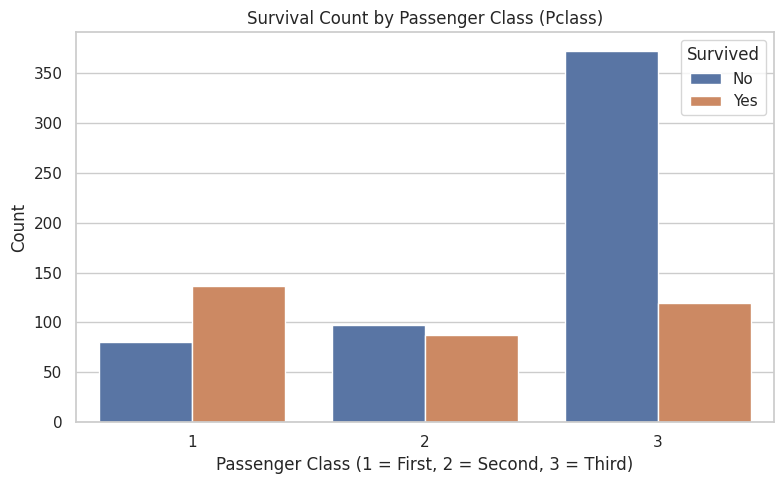

In [7]:
# Figure 1: Survival by passenger class
ax = sns.countplot(data=df_clean, x='Pclass', hue='Survived')
ax.set_title('Survival Count by Passenger Class (Pclass)')
ax.set_xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
ax.set_ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

*Interpretation:* First class had a higher proportion of survivors; third class had the most passengers but the fewest survivors, consistent with deck access and lifeboat priority.

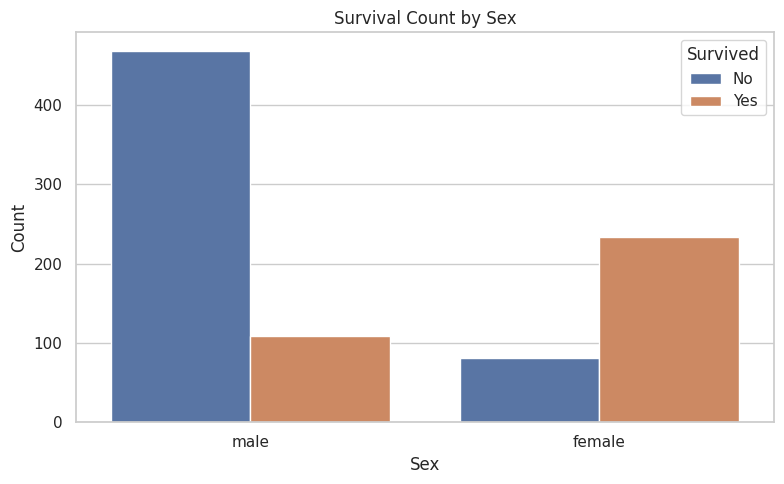

In [8]:
# Figure 2: Survival by sex
ax = sns.countplot(data=df_clean, x='Sex', hue='Survived')
ax.set_title('Survival Count by Sex')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

*Interpretation:* Female passengers had a much higher survival rate than males, consistent with "women and children first" during evacuation.

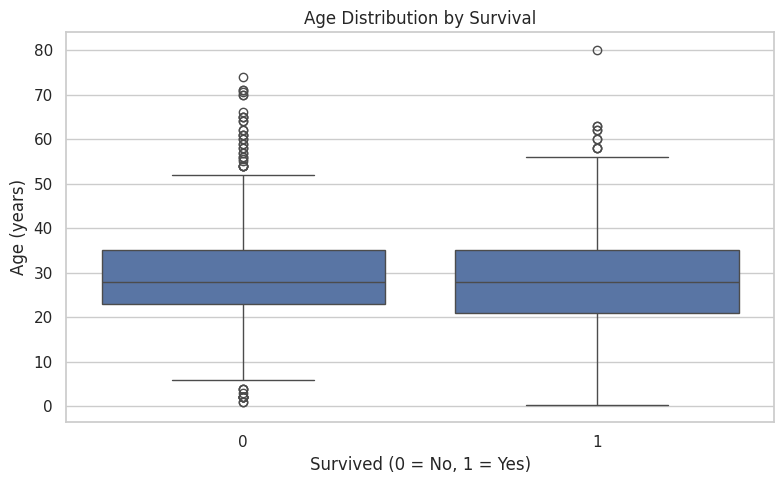

In [9]:
# Figure 3: Age distribution by survival
fig, ax = plt.subplots()
sns.boxplot(data=df_clean, x='Survived', y='Age', ax=ax)
ax.set_title('Age Distribution by Survival')
ax.set_xlabel('Survived (0 = No, 1 = Yes)')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

*Interpretation:* Survivors tend to have a slightly younger age distribution (e.g. more children); the boxplot shows median and spread of age for each group.

## 6. Summary and Interpretation

### What I learned
- **Class mattered:** First-class passengers had a higher survival rate than second and third class, consistent with "women and children first" and better access to lifeboats for upper decks.
- **Sex was a strong predictor:** Female passengers survived at a much higher rate than males, aligning with the historical evacuation policy.
- **Age:** After filling missing ages with the median, the distribution by survival shows that survivors tended to include more younger passengers (e.g., children prioritized). The median age among survivors is slightly lower than among non-survivors.

### Interesting patterns
- Pclass and Sex interact: first-class women had very high survival; third-class men had very low survival.
- Fare is correlated with Pclass; we did not add a separate Fare plot but it reinforces the class effect.

### Limitations and assumptions
- **Missing data:** We imputed Age with the median and Embarked with the mode. This can smooth out real differences (e.g., if missingness were related to survival).
- **Redundant columns:** We dropped Cabin because it was mostly missing; retaining it could allow "Cabin known vs unknown" as a proxy for deck/location.
- The dataset is a single train split; conclusions are observational, not causal.

### Surprising or unclear
- Some third-class passengers did survive; exploring family size (SibSp + Parch) might explain part of that. The overall pattern is clear despite noise in the data.